In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('/Users/sam/Documents/DI_DATA_2025/week9/day2/imdb_top_1000.csv')

# Quick overview
print(df.shape)
print(df.columns)
df.head()

(1000, 16)
Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [2]:
# Inspect data types and nulls
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [3]:
# Clean 'Runtime' column
df['Runtime'] = df['Runtime'].str.replace(' min', '').astype(float)

# Convert 'Released_Year' to numeric
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

# Remove '$' and ',' from 'Gross' and convert to numeric
df['Gross'] = df['Gross'].replace('[\$,]', '', regex=True).astype(float)

# Clean 'Meta_score'
df['Meta_score'] = pd.to_numeric(df['Meta_score'], errors='coerce')

# Drop rows with too many missing values or fill them
df.dropna(subset=['IMDB_Rating', 'Released_Year'], inplace=True)
df.fillna({'Meta_score': df['Meta_score'].median(), 'Gross': df['Gross'].median()}, inplace=True)

<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_65125/3696380582.py:8: SyntaxWarning: invalid escape sequence '\$'
  df['Gross'] = df['Gross'].replace('[\$,]', '', regex=True).astype(float)


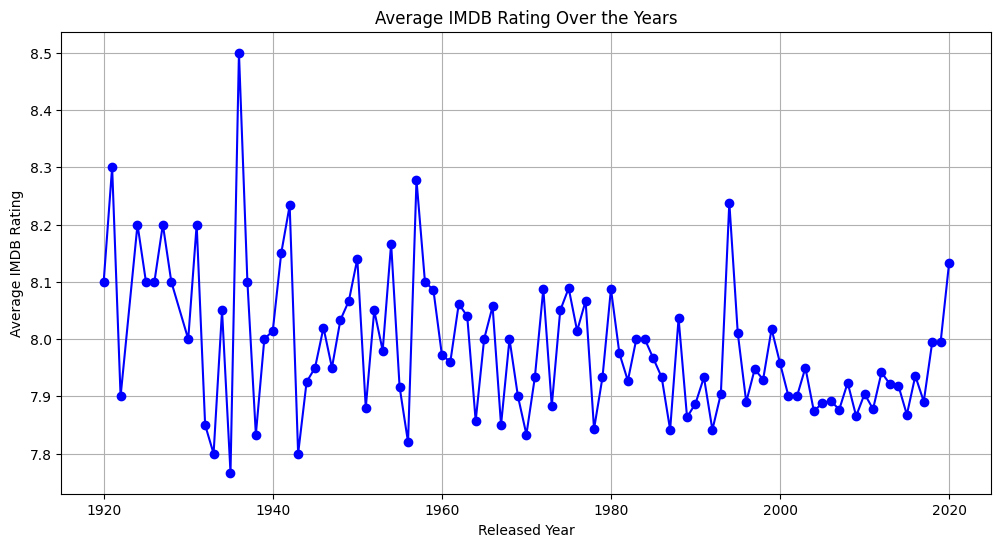

In [4]:
import matplotlib.pyplot as plt

# Average rating by year
rating_trend = df.groupby('Released_Year')['IMDB_Rating'].mean()

plt.figure(figsize=(12,6))
plt.plot(rating_trend.index, rating_trend.values, marker='o', color='blue')
plt.title('Average IMDB Rating Over the Years')
plt.xlabel('Released Year')
plt.ylabel('Average IMDB Rating')
plt.grid(True)
plt.show()

/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_65125/921864070.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_exploded, x='Genre', order=df_exploded['Genre'].value_counts().index, palette='viridis')


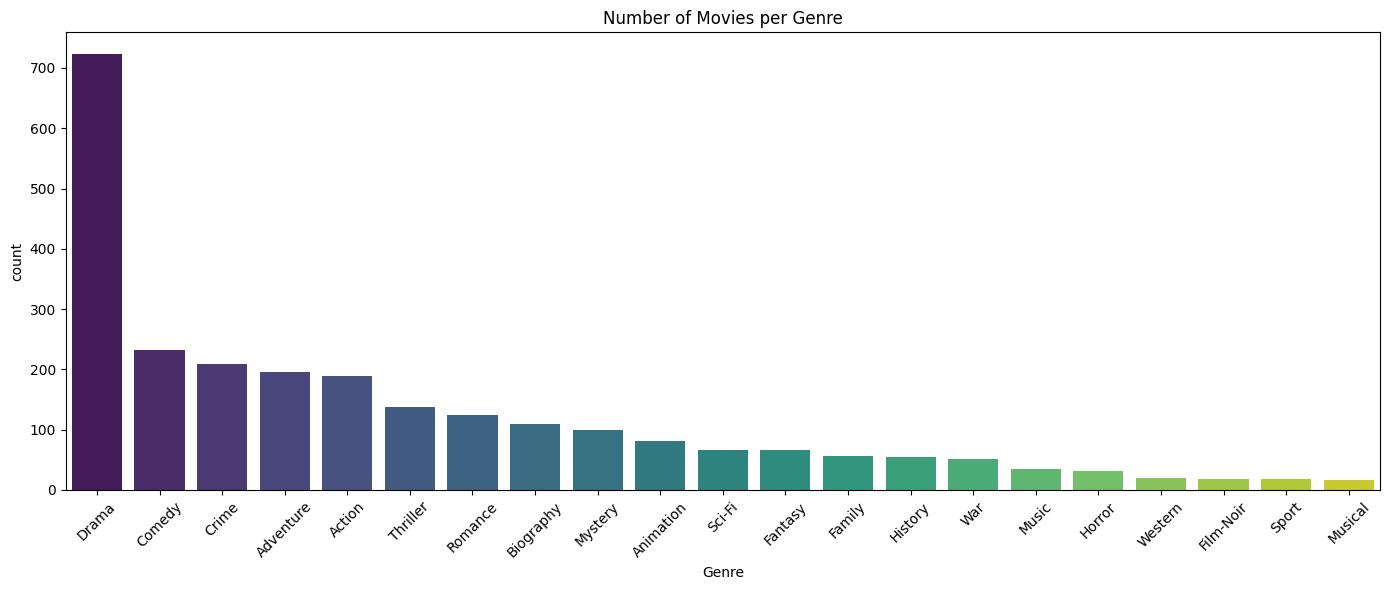

In [5]:
import seaborn as sns

# Expand genres into multiple rows
df_exploded = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')

plt.figure(figsize=(14,6))
sns.countplot(data=df_exploded, x='Genre', order=df_exploded['Genre'].value_counts().index, palette='viridis')
plt.title('Number of Movies per Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

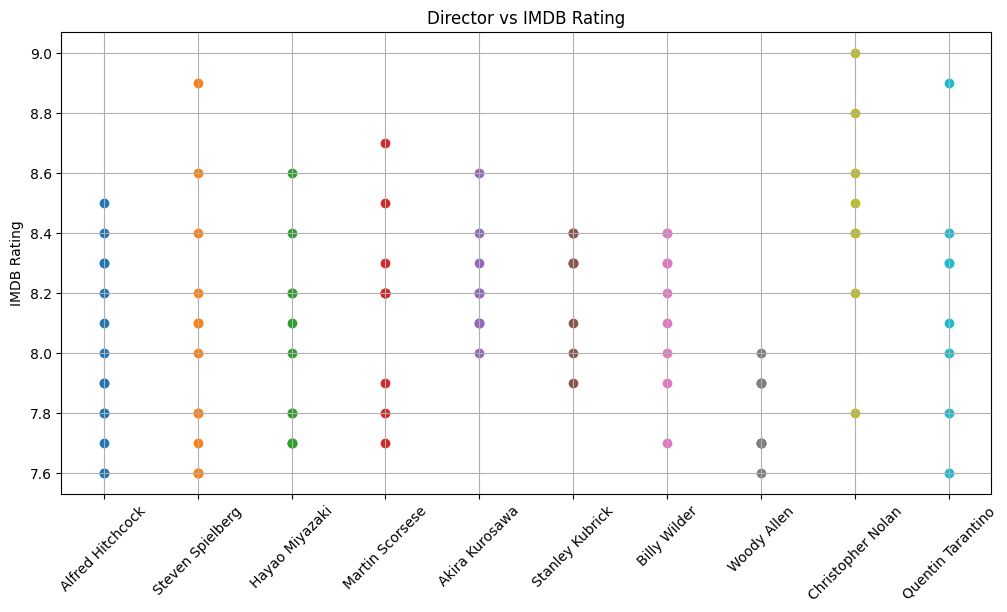

In [6]:
top_directors = df['Director'].value_counts().head(10).index
df_top_directors = df[df['Director'].isin(top_directors)]

plt.figure(figsize=(12,6))
for director in top_directors:
    subset = df_top_directors[df_top_directors['Director'] == director]
    plt.scatter(subset['Director'], subset['IMDB_Rating'], label=director)

plt.title('Director vs IMDB Rating')
plt.ylabel('IMDB Rating')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

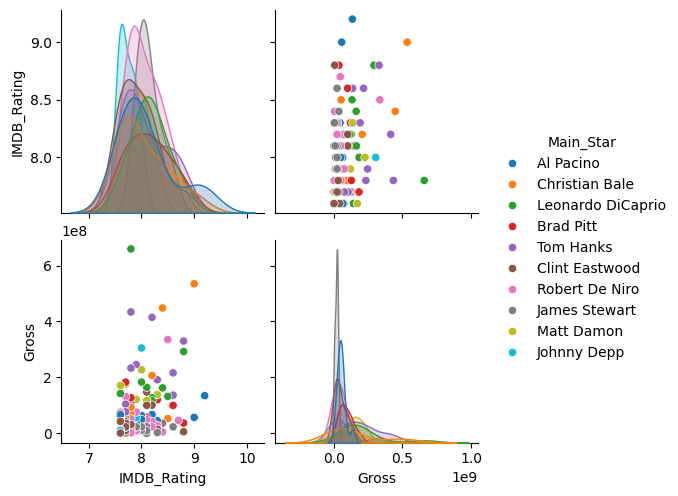

In [9]:
import seaborn as sns

# Combine all star columns into one column
df_all_stars = pd.melt(df, value_vars=['Star1', 'Star2', 'Star3', 'Star4'], value_name='Star')

# Identify the top 10 most frequent actors
top_all_stars = df_all_stars['Star'].value_counts().head(10).index

# Create a new column 'Main_Star' that contains one of the top actors if present in a movie
df['Main_Star'] = df[['Star1', 'Star2', 'Star3', 'Star4']].apply(
    lambda row: next((star for star in row if star in top_all_stars), None), axis=1
)

# Filter rows where a top actor was found
df_top_all_stars = df[df['Main_Star'].notnull()]

# Visualize relationships using pairplot
sns.pairplot(df_top_all_stars[['IMDB_Rating', 'Gross', 'Main_Star']], hue='Main_Star', height=2.5)

/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_65125/3534514553.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exploded, x='Genre', y='IMDB_Rating', palette='Set2')


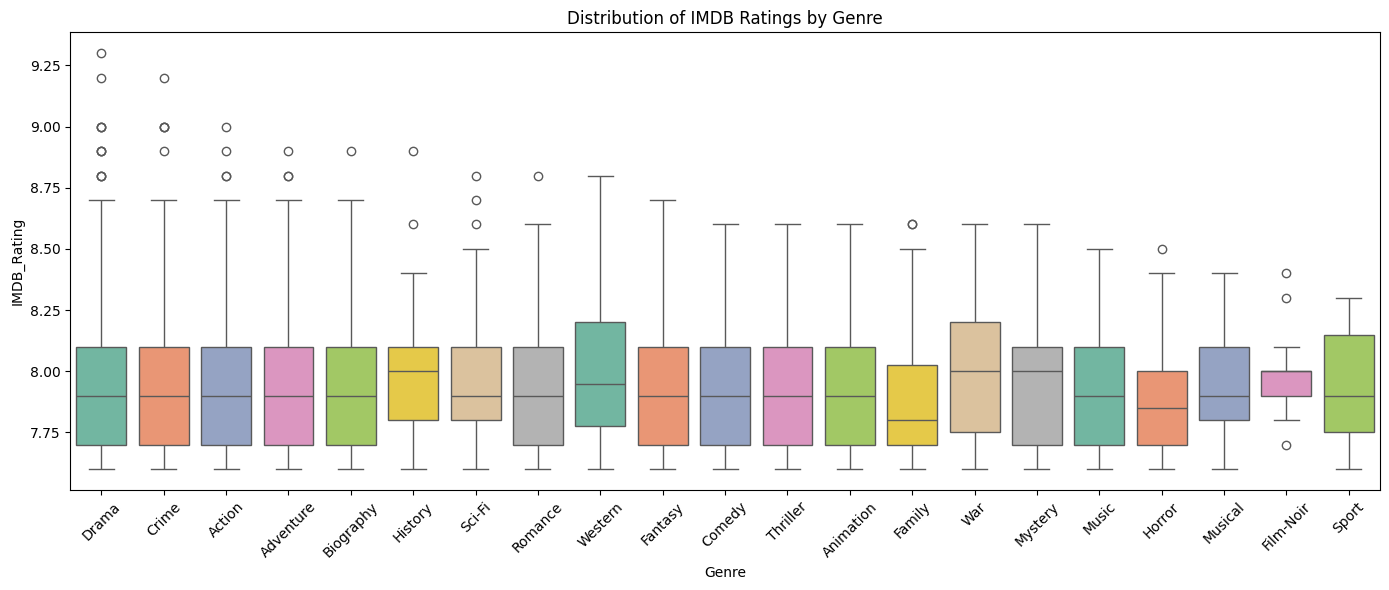

In [10]:
# Explode genre into multiple rows
df_exploded = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')

# Boxplot to show distribution of ratings by genre
plt.figure(figsize=(14,6))
sns.boxplot(data=df_exploded, x='Genre', y='IMDB_Rating', palette='Set2')
plt.title('Distribution of IMDB Ratings by Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

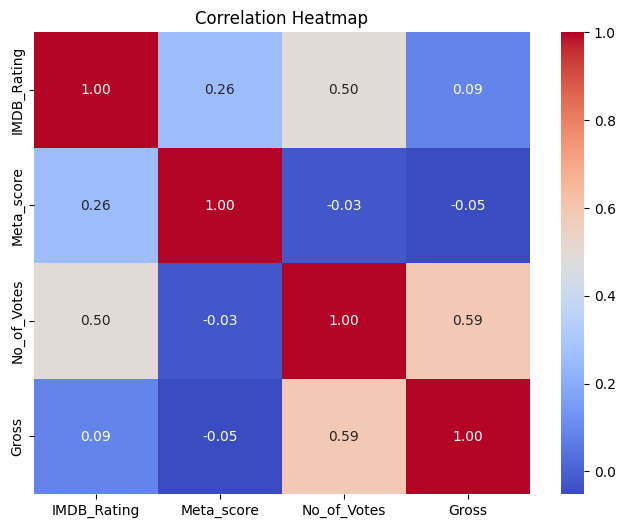

In [11]:
# Select numerical features for correlation
corr = df[['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']].corr()

# Create heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()